# Comparing Model Densities

In [85]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from flax import nnx
from confrdm_jax.flows import evaluate_pdf_sf
from confrdm_jax.flows import load_conditioner
from confrdm_jax.flows import make_mlp_conditioner
from confrdm_jax.likelihoods import inv_gauss_log_pdf_sf
from confrdm_jax.simulators import create_crdm_single_prior_informed
from confrdm_jax.simulators import create_wald_prior_informed
from confrdm_jax.simulators import sample_conditional_crdm_single
from confrdm_jax.simulators import sample_conditional_wald

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [86]:
num_trials = 500
num_datasets = 10

In [87]:
master_key = jax.random.key(2025)
conditioner_key, test_key = jax.random.split(master_key)

rngs = nnx.Rngs(default=conditioner_key)

## Racing Diffusion Model

In [88]:
num_bins = 12
num_mid = 128
train_steps = 200_000

config_path = f"model.num_bins={num_bins}/model.num_mid={num_mid}/optimizer=adam_cosine_decay/train_steps={train_steps}/conditioner"

In [89]:
prior_rdm = create_wald_prior_informed()

conditioner_rdm = load_conditioner(
    make_mlp_conditioner(num_in=3, num_bins=num_bins, num_mid=num_mid, rngs=rngs),
    Path("../outputs/rdm").absolute() / config_path
)
conditioner_rdm.eval()

In [90]:
test_data, test_context = sample_conditional_wald(test_key, (num_datasets, num_trials), prior_rdm)

test_pdf, test_sf = nnx.jit(evaluate_pdf_sf)(conditioner_rdm, test_data.squeeze(), test_context)

In [91]:
test_pdf.shape

(10, 500)

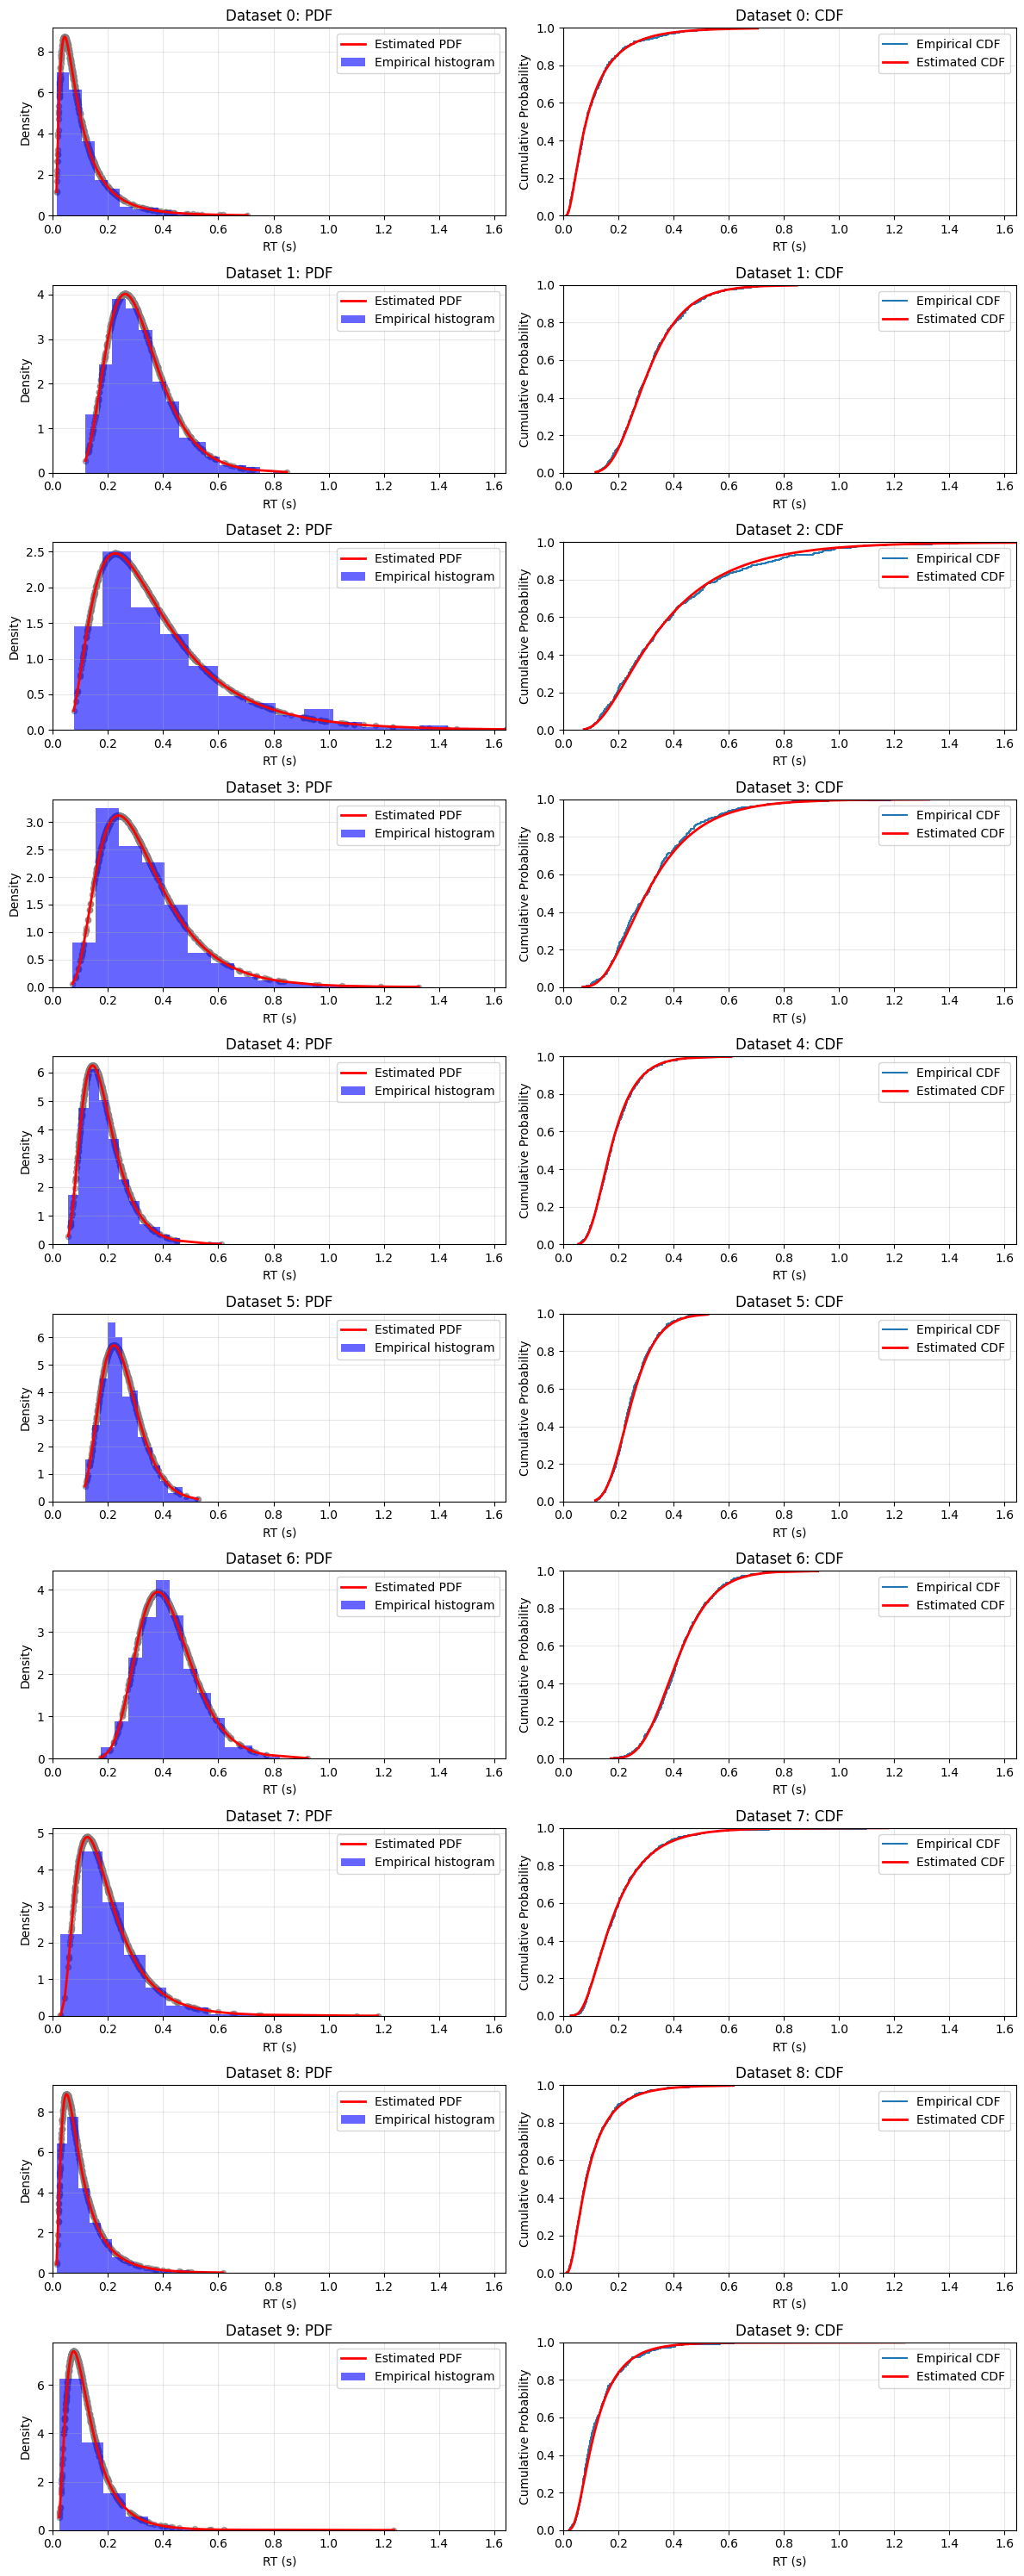

In [92]:
def plot_pdf_cdf_comparison(test_data, test_pdf, test_sf, figsize=(12, 3)):
    num_datasets = test_data.shape[0]
    fig, axes = plt.subplots(num_datasets, 2, figsize=(figsize[0], num_datasets * figsize[1]))
    
    if num_datasets == 1:
        axes = axes.reshape(1, -1)
    
    for i in range(num_datasets):
        data = test_data[i]
        pdf = jnp.exp(test_pdf[i])
        sf = jnp.exp(test_sf[i])
        cdf = 1 - sf
        
        sorted_indices = jnp.argsort(data)
        sorted_data = data[sorted_indices]
        sorted_pdf = pdf[sorted_indices]
        sorted_cdf = cdf[sorted_indices]
        
        axes[i, 0].scatter(data, pdf, alpha=0.6, s=20, color="grey")
        axes[i, 0].plot(sorted_data, sorted_pdf, 'r-', linewidth=2, label='Estimated PDF')
        axes[i, 0].hist(sorted_data, color="blue", alpha=0.6, density=True, bins=15, label="Empirical histogram")
        axes[i, 0].set_xlim((0.0, test_data.max()))
        axes[i, 0].set_xlabel('RT (s)')
        axes[i, 0].set_ylabel('Density')
        axes[i, 0].set_title(f'Dataset {i}: PDF')
        axes[i, 0].legend()
        axes[i, 0].grid(True, alpha=0.3)
        
        axes[i, 1].ecdf(sorted_data, label="Empirical CDF")
        axes[i, 1].plot(sorted_data, sorted_cdf, 'r-', linewidth=2, label='Estimated CDF')
        axes[i, 1].set_xlim((0.0, test_data.max()))
        axes[i, 1].set_xlabel('RT (s)')
        axes[i, 1].set_ylabel('Cumulative Probability')
        axes[i, 1].set_title(f'Dataset {i}: CDF')
        axes[i, 1].legend()
        axes[i, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    return fig, axes

fig, axes = plot_pdf_cdf_comparison(test_data.squeeze(), test_pdf, test_sf)
plt.savefig("densities/pdf_cdf_rdm.png")
plt.show()

In [93]:
test_context.shape

(10, 1, 3)

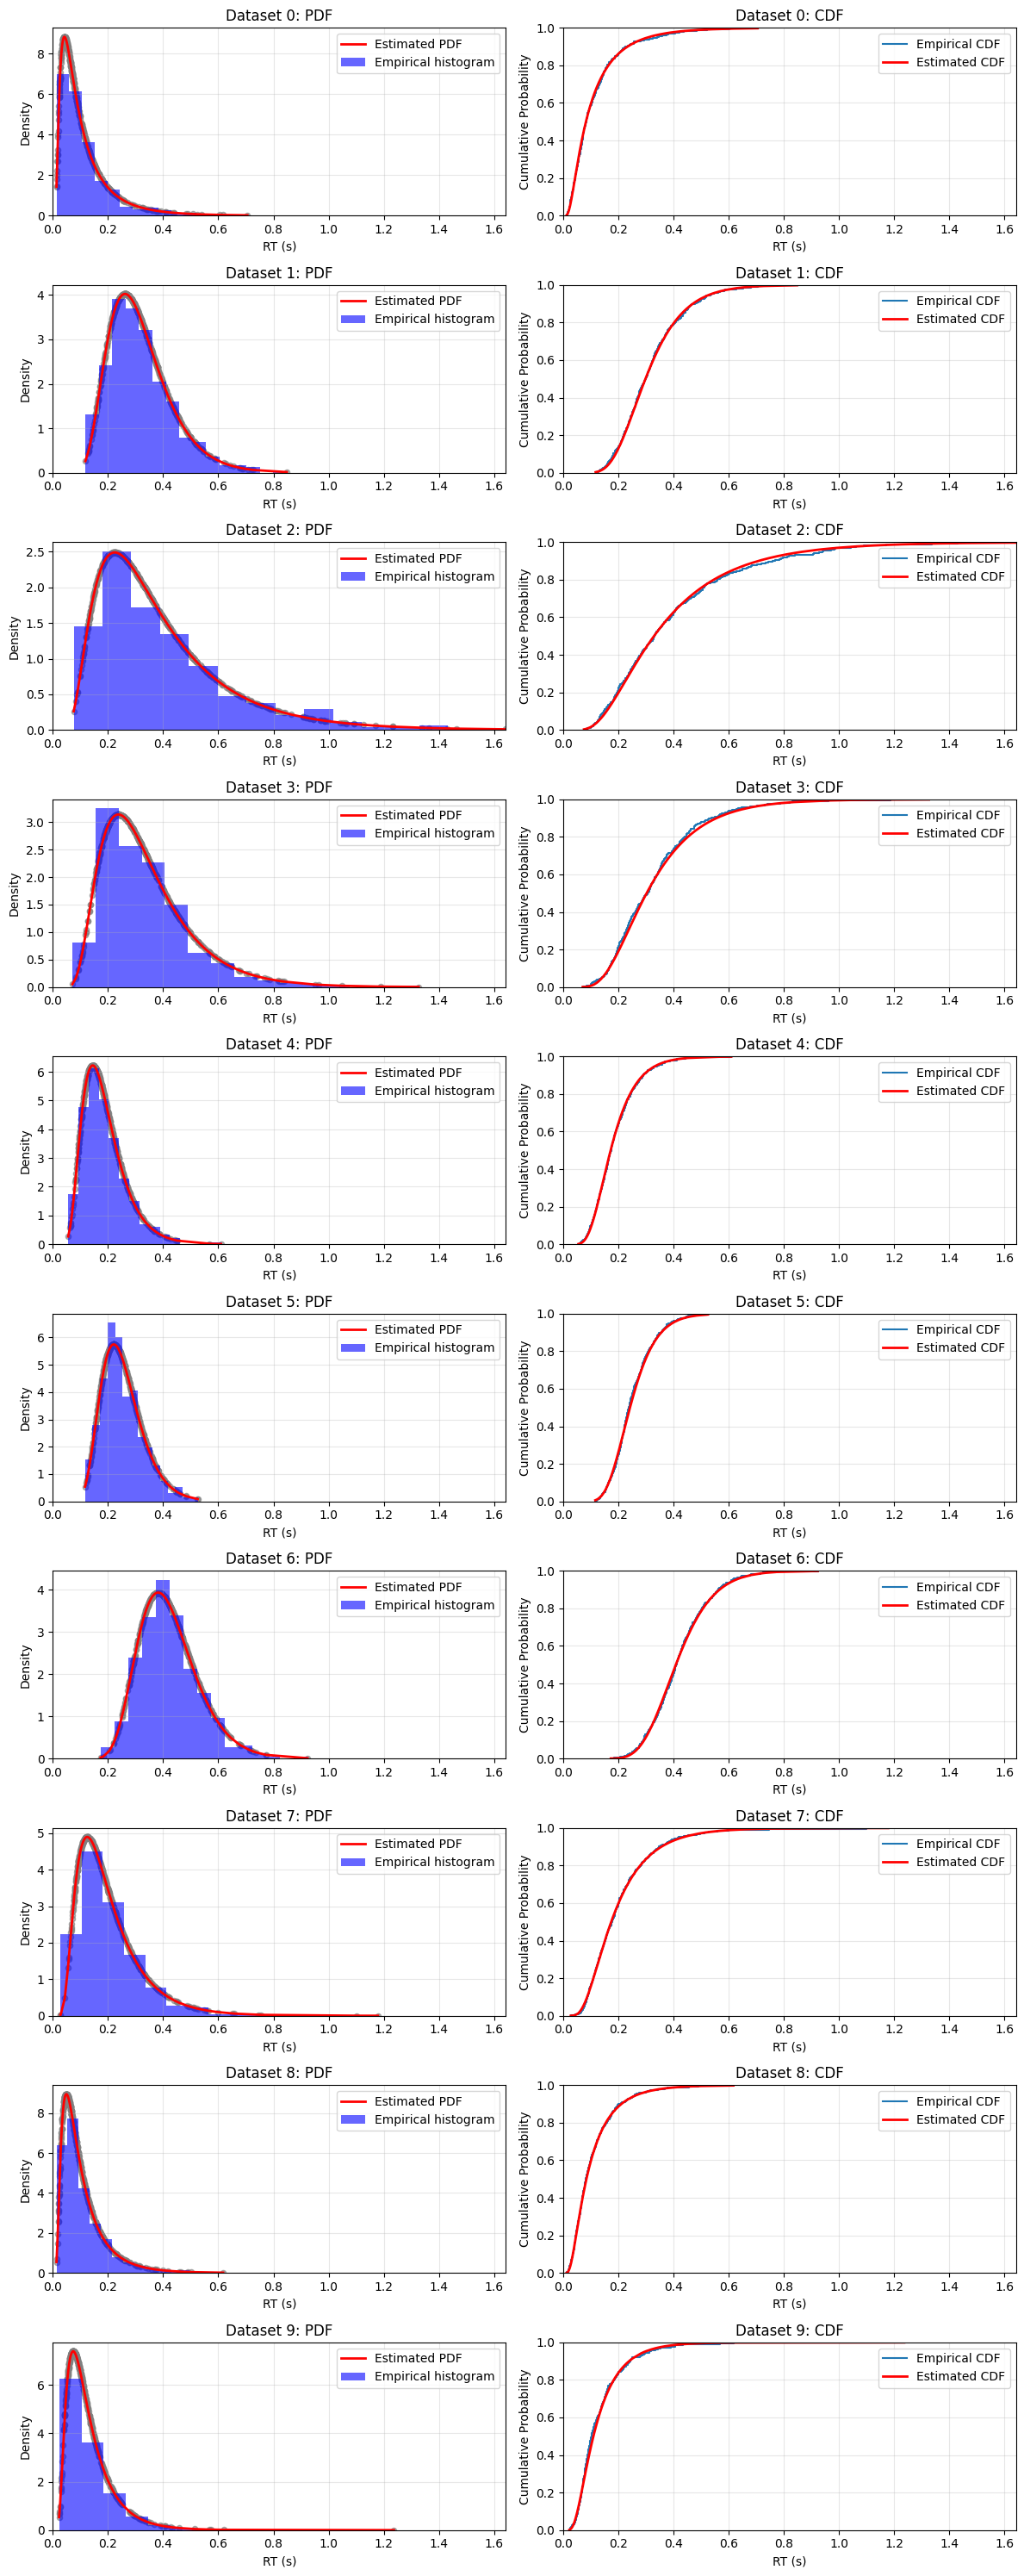

In [94]:
test_pdf_ref, test_sf_ref = inv_gauss_log_pdf_sf(test_data, test_context[..., :1], test_context[..., 1:2], test_context[..., 2:], jnp.zeros_like(test_context[..., :1]))

plot_pdf_cdf_comparison(test_data.squeeze(), test_pdf_ref.squeeze(), test_sf_ref.squeeze());

# Conflict Racing Diffusion Model

In [95]:
num_bins = 12
num_mid = 128
train_steps = 500_000

dt = 0.0005

config_path = f"model.dt={dt}/model.num_bins={num_bins}/model.num_mid={num_mid}/optimizer=adam_cosine_decay/train_steps={train_steps}/conditioner"

In [96]:
prior_crdm = create_crdm_single_prior_informed()

conditioner_crdm = load_conditioner(
    make_mlp_conditioner(num_in=5, num_bins=num_bins, num_mid=num_mid, rngs=rngs),
    Path("../outputs/crdm").absolute() / config_path
)
conditioner_crdm.eval()

In [97]:
test_data, test_context = sample_conditional_crdm_single(test_key, (num_datasets, num_trials), prior_crdm, dt, 4.0)

test_pdf, test_sf = nnx.jit(evaluate_pdf_sf)(conditioner_crdm, test_data.squeeze(), test_context)

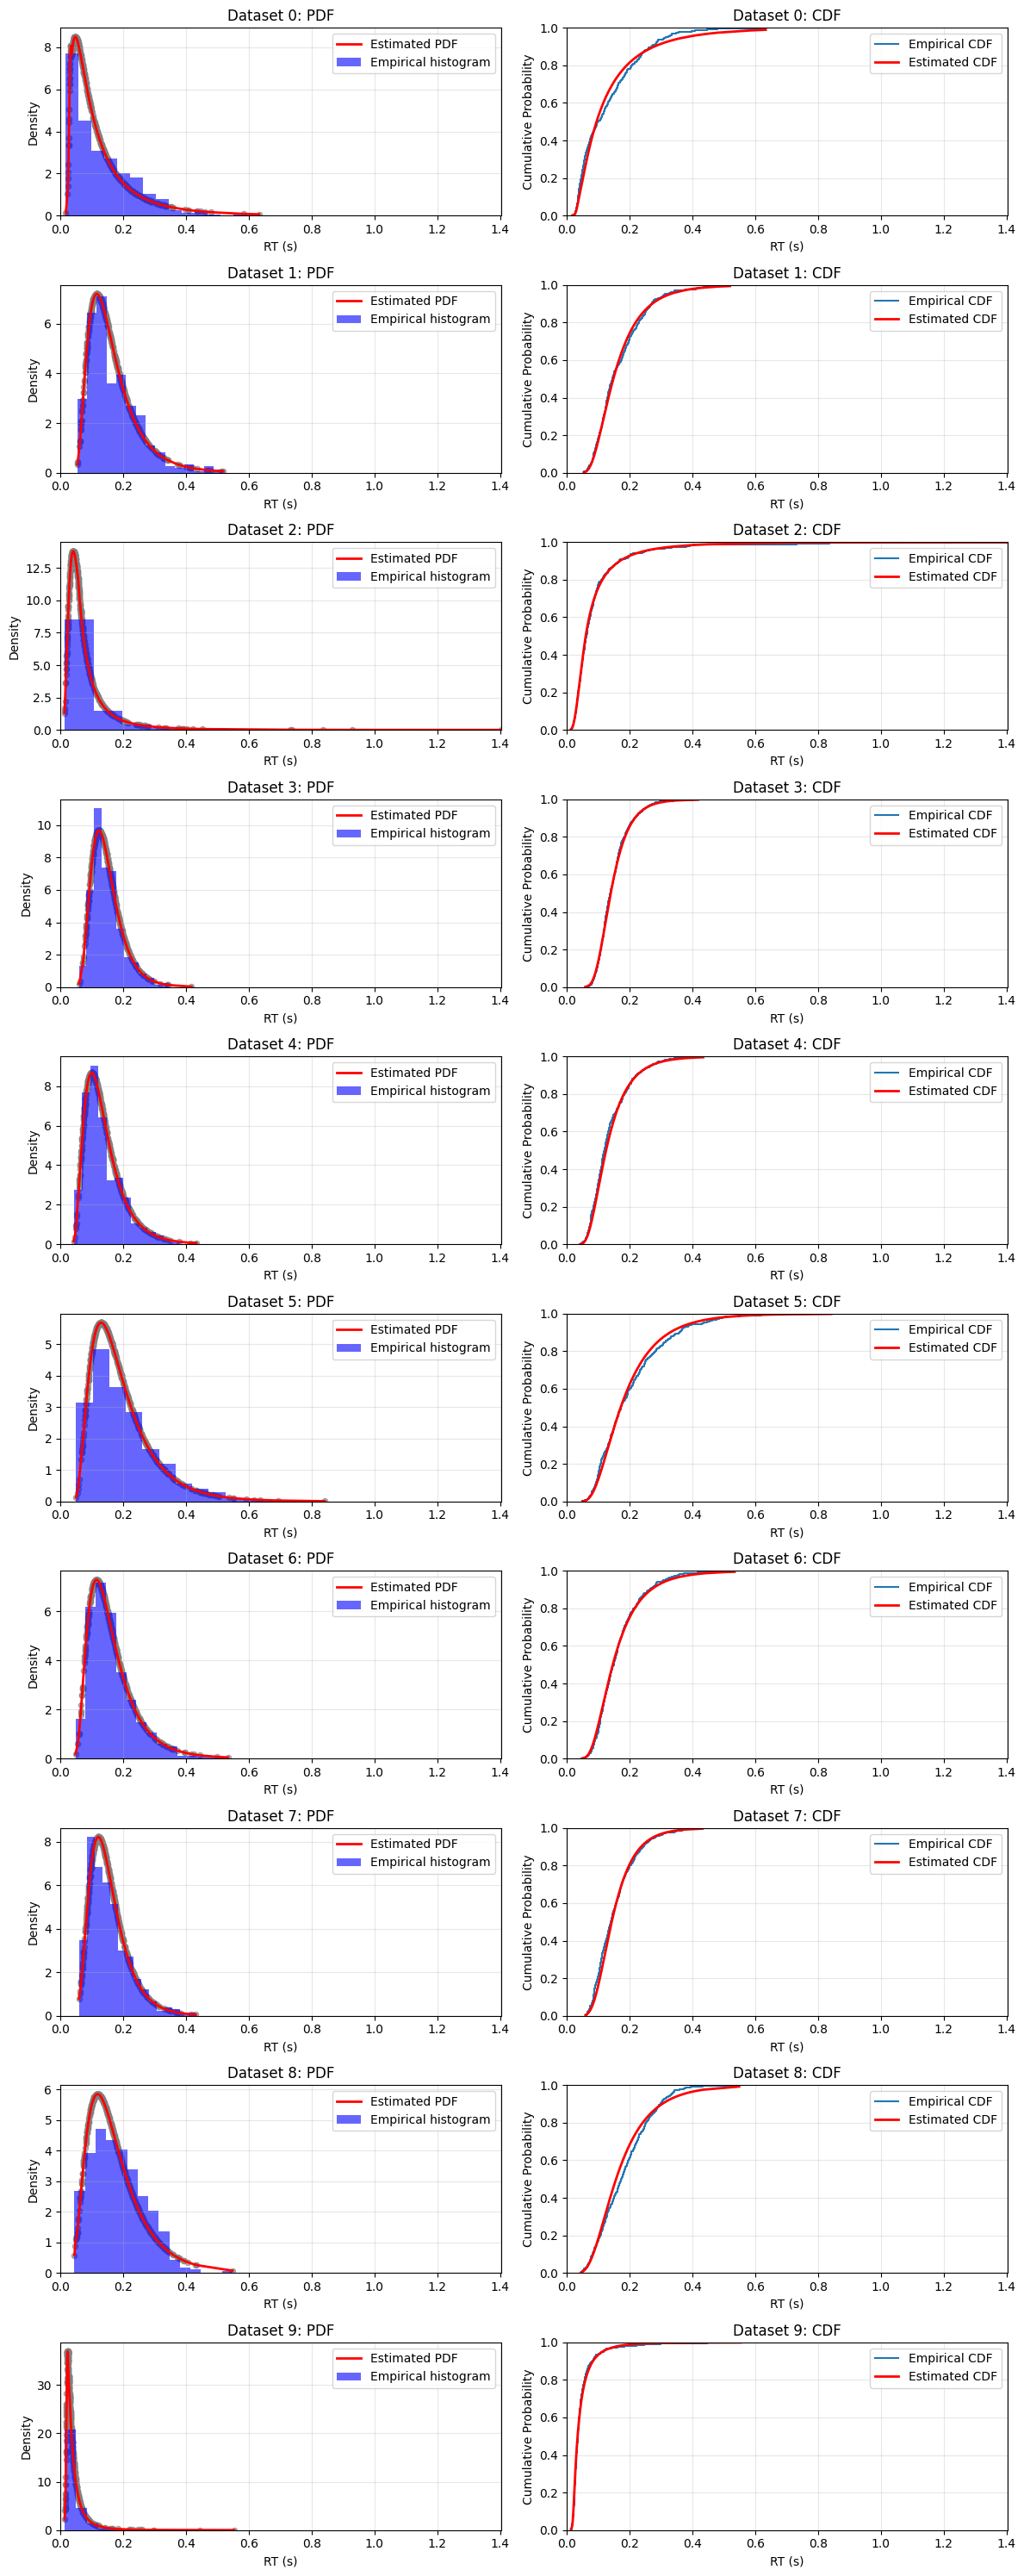

In [98]:
fig, axes = plot_pdf_cdf_comparison(test_data.squeeze(), test_pdf, test_sf)
plt.savefig("densities/pdf_cdf_crdm.png")
plt.show()